In [1]:
"""
Task 4: BESS Capacity/Power Sensitivity
"""

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# Load, generation, and tariffs
# ==============================================================================
def read_load_generation(load_file, pv_file):
    """
    Read load and generation from CSV files
    """
    df_load = pd.read_csv(load_file)
    df_pv = pd.read_csv(pv_file)

    dates = df_load.iloc[:, 0].astype(str).tolist()

    load_profiles = df_load.iloc[:, 1:].values.flatten()
    pv_profiles = df_pv.iloc[:, 1:].values.flatten()
    days = len(df_load)

    return load_profiles, pv_profiles, days, dates


def generate_eta_profiles(days, steps_per_day):
    """
    Generates the daily time-of-use tariff and copies it
    across the entire multi-day horizon.
    """
    eta_day = np.zeros(steps_per_day)
    eta_day[np.r_[0:14, 44:48]] = 0.03   # Off-peak rate ($/kWh)
    eta_day[np.r_[14:28, 40:44]] = 0.06  # Shoulder rate ($/kWh)
    eta_day[28:40]               = 0.30  # Peak rate ($/kWh)

    eta_profiles = np.tile(eta_day, days)
    return eta_profiles

# ==============================================================================
# Core algorithmic function definitions: MPC QP
# ==============================================================================
def solve_mpc_step(p_load_pred, p_pv_pred, eta_pred, z_current, N, delta, p_min, p_max, c_max, w):
    x1 = cp.Variable(N)
    x2 = cp.Variable(N)
    z  = cp.Variable(N+1)

    # =========================================================================
    # @TODO: Paste your completed objective from MPC Task 1 here:
    #   min sum_k [ -delta * eta_pred(k) * x1(k) + w * eta_pred(k) * (x2(k))^2 ]
    # =========================================================================

    # objective = None # old objective function skeleton code
    objective = cp.Minimize(cp.sum(-delta * cp.multiply(eta_pred, x1) + w * cp.multiply(eta_pred, cp.square(x2))))

    constraints = [
        x2 == p_load_pred - p_pv_pred - x1,
        x1 >= p_min, x1 <= p_max,
        z >= 0.0, z <= c_max,
        z[0] == z_current
    ]
    # =========================================================================
    # Battery-energy dynamics: LaTeX indexing versus Python indexing
    # -------------------------------------------------------------------------
    # The mathematical MPC model uses horizon steps k = 1,...,N:
    #
    #     z(t+k|t) = z(t+k-1|t) - delta*x1(t+k|t)
    #
    # with:
    #
    #     z(t|t)   = measured battery energy at the current time, and
    #     z(t+N|t) = z(t|t) for the cyclic terminal condition.
    #
    # Python arrays use zero-based indexing, and the state vector contains
    # one more element than the dispatch vector:
    #
    #     z[0],...,z[N]
    #         <-> z(t|t), z(t+1|t),...,z(t+N|t)
    #
    #     x1[0],...,x1[N-1]
    #         <-> x1(t+1|t),...,x1(t+N|t)
    #
    # Therefore:
    #
    #     z[k+1] = z[k] - delta*x1[k],    k = 0,...,N-1
    #
    # This is the same recurrence as the LaTeX equation, expressed using
    # Python's zero-based indexing. The N+1 state values represent the
    # current state plus one boundary state after each of the N dispatch steps.
    # =========================================================================
    for k in range(N):
        constraints += [z[k+1] == z[k] - delta * x1[k]]

    constraints += [z[N] == z[0]]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    if prob.status != cp.OPTIMAL:
        print(f"Warning: MPC subproblem failed to solve. Status: {prob.status}")

    return x1.value, x2.value, z.value


def run_mpc_loop(sim_steps, N_pred, delta, load_profiles, pv_profiles, eta_profiles, p_min, p_max, c_max, z_init, w):
    """
    Executes the receding-horizon mechanism: predicts, solves, executes the 1st step,
    and advances the system state forward.
    """
    executed_x1_BESS = np.zeros(sim_steps)
    executed_x2_grid = np.zeros(sim_steps)
    executed_z_SOC   = np.zeros(sim_steps)

    current_z = z_init

    for t in range(sim_steps):
        p_load_pred = load_profiles[t : t + N_pred]
        p_pv_pred   = pv_profiles[t : t + N_pred]
        eta_pred    = eta_profiles[t : t + N_pred]

        x1_pred, x2_pred, z_pred = solve_mpc_step(
            p_load_pred, p_pv_pred, eta_pred, current_z, N_pred, delta, p_min, p_max, c_max, w
        )

        executed_x1_BESS[t] = x1_pred[0]
        executed_x2_grid[t] = x2_pred[0]
        executed_z_SOC[t]   = current_z

        current_z = current_z - delta * x1_pred[0]

    return executed_x1_BESS, executed_x2_grid, executed_z_SOC


GROUP A: Fixed Capacity, Varying Power
Power Scale: 0.10x | P_max:   665.0 kW | Bill: $  5725.70
Power Scale: 0.15x | P_max:   997.5 kW | Bill: $  4790.04
Power Scale: 0.20x | P_max:  1330.0 kW | Bill: $  4321.35
Power Scale: 0.50x | P_max:  3325.0 kW | Bill: $  3400.15
Power Scale: 1.00x | P_max:  6650.0 kW | Bill: $  3400.15

GROUP B: Fixed Power, Varying Capacity
Capacity Scale: 0.5x | C_max:    6650 kWh | Bill: $  4654.77
Capacity Scale: 1.0x | C_max:   13300 kWh | Bill: $  3400.15
Capacity Scale: 2.0x | C_max:   26600 kWh | Bill: $  2991.88
Capacity Scale: 3.0x | C_max:   39900 kWh | Bill: $  3254.30
Capacity Scale: 4.0x | C_max:   53200 kWh | Bill: $  3348.82


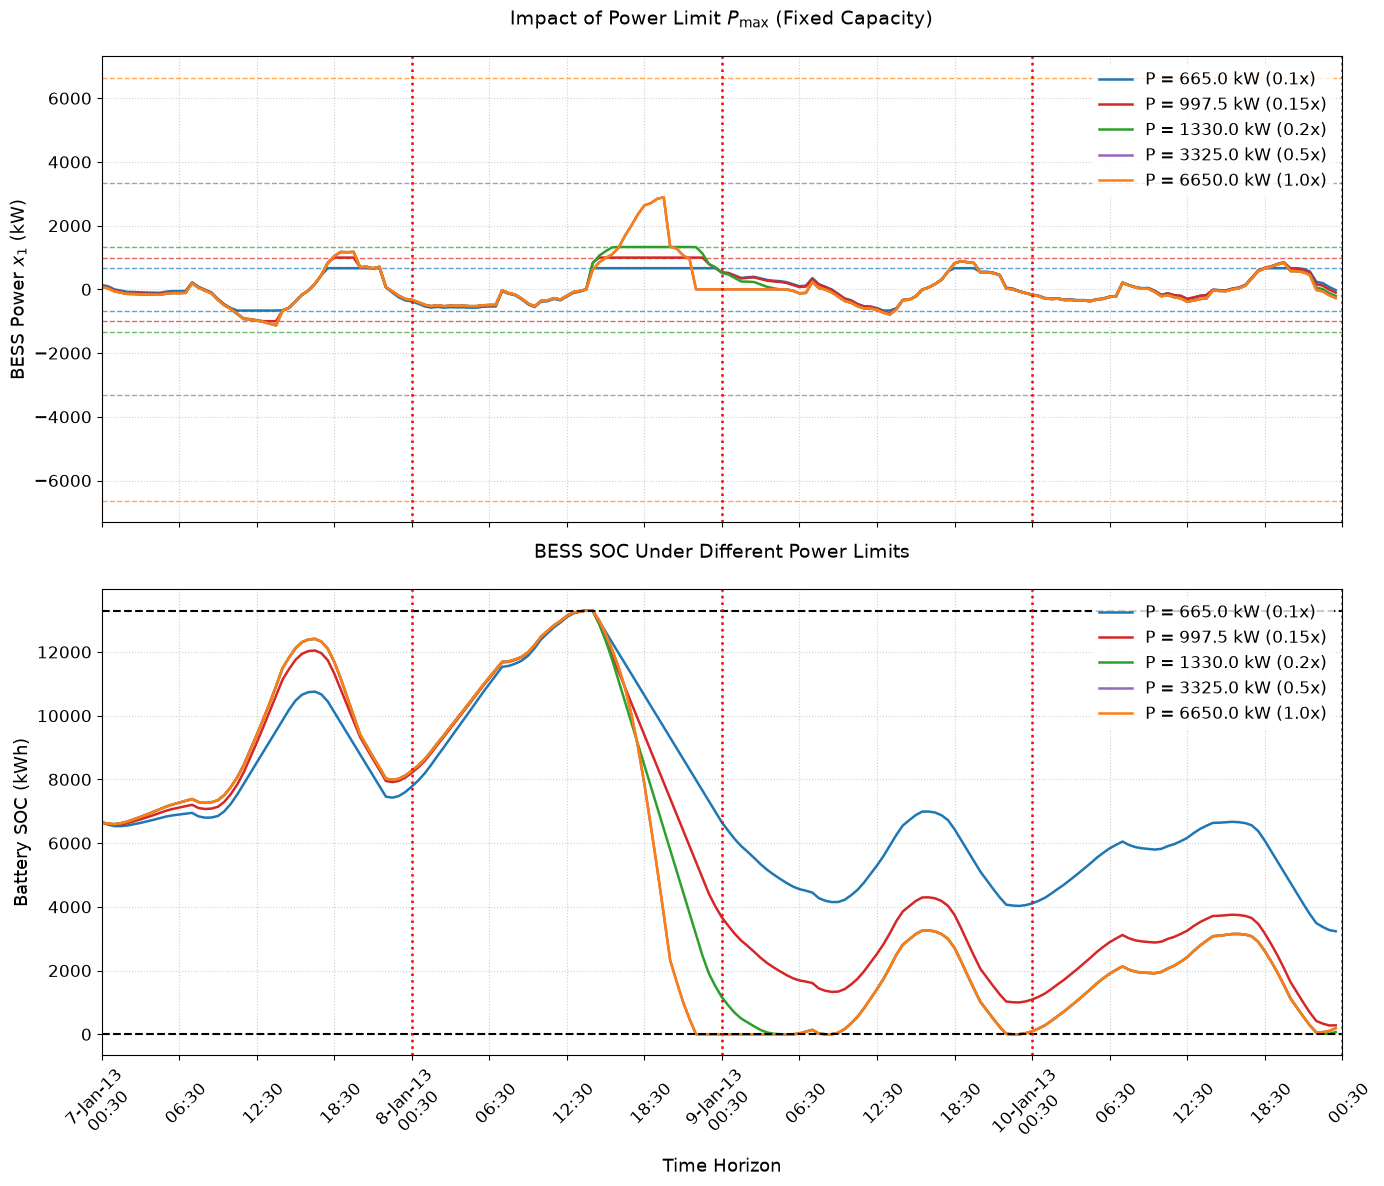

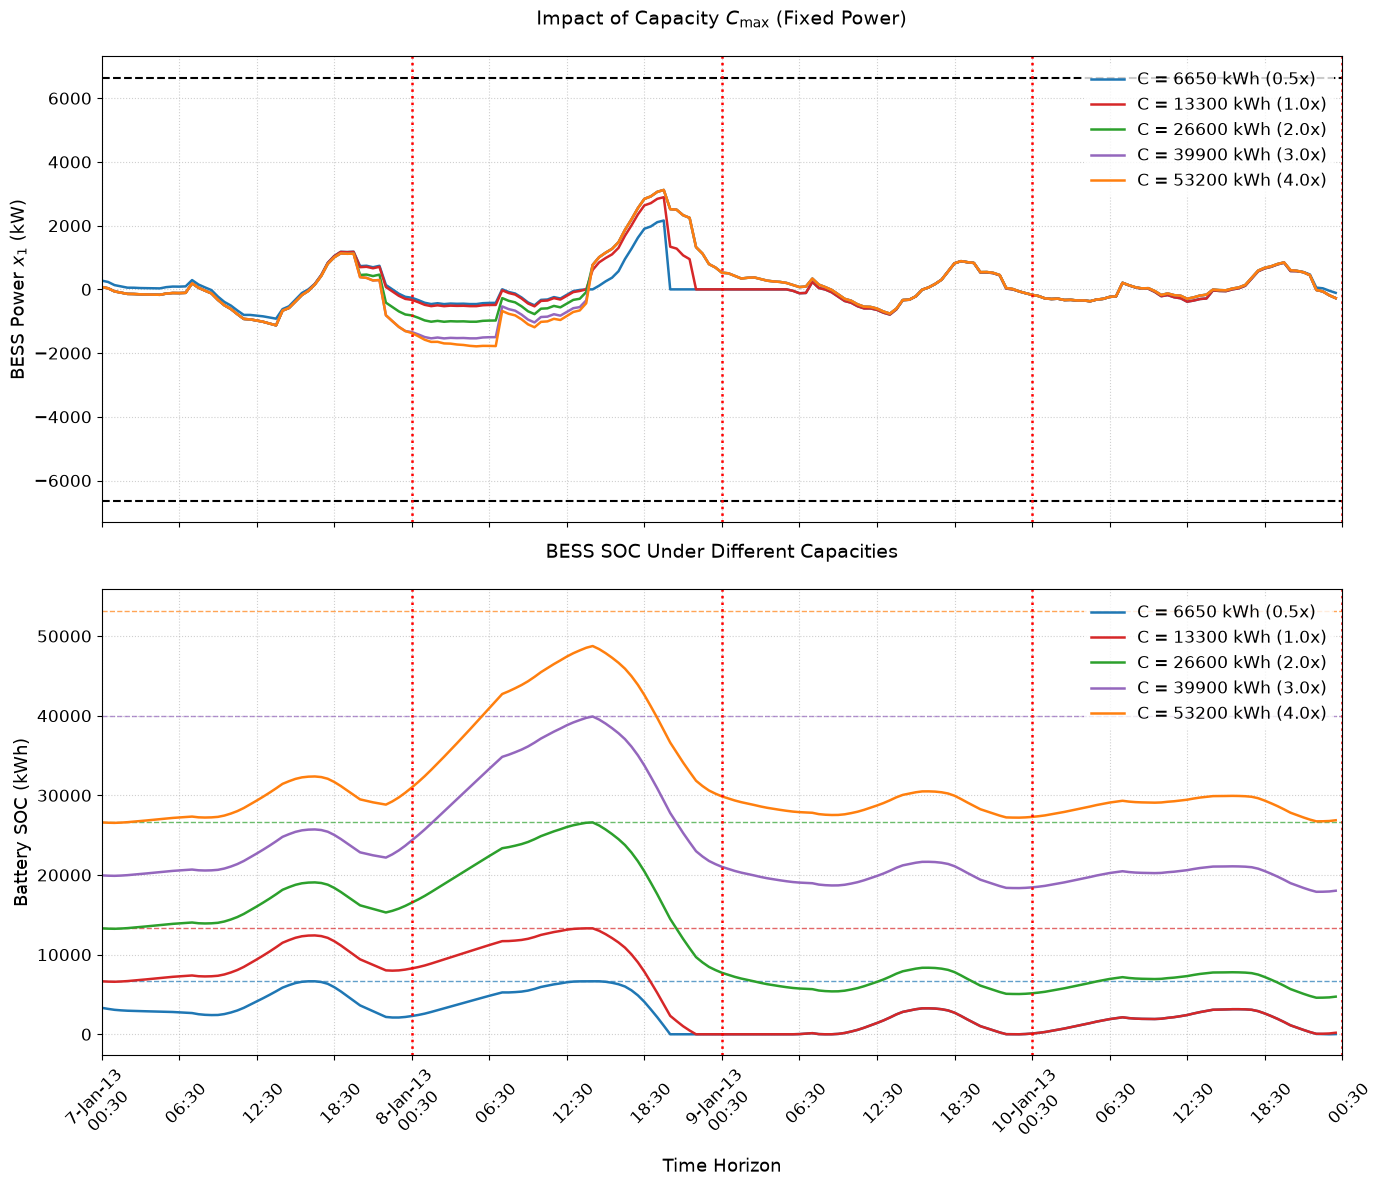

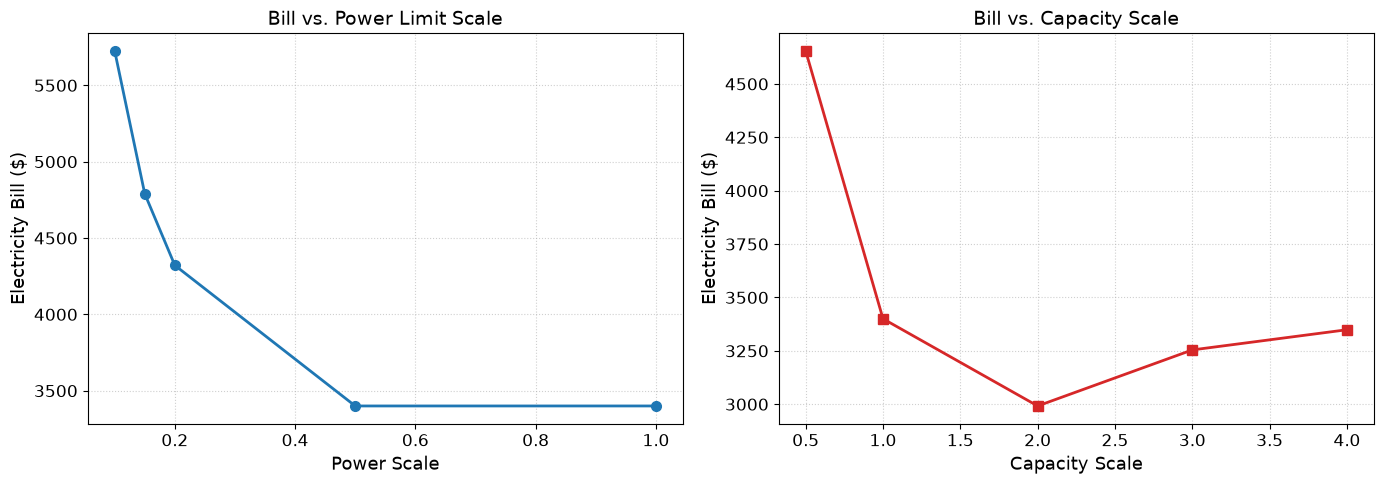

In [2]:
"""
Main Execution
"""

steps_per_day = 48
delta = 0.5
w = 1

load_csv_path = 'perfect_load.csv'
pv_csv_path = 'perfect_pv.csv'
load_profiles, pv_profiles, total_days, dates = read_load_generation(load_csv_path, pv_csv_path)

pred_days = 1
N_pred = pred_days * steps_per_day
sim_days = total_days - pred_days
sim_steps = sim_days * steps_per_day

eta_profiles = generate_eta_profiles(total_days, steps_per_day)

total_customers = 1330
base_p_max = 5.0 * total_customers
base_c_max = 10.0 * total_customers

time_indices_sim = np.arange(sim_steps)
timeline_sim = time_indices_sim * delta

p_scales = [0.1, 0.15, 0.2, 0.5, 1.0]
c_scales = [0.5, 1.0, 2.0, 3.0, 4.0]

print("=" * 60)
print("GROUP A: Fixed Capacity, Varying Power")
print("=" * 60)
mpc_results_GroupA = {}
for s in p_scales:
    c_max_test = base_c_max
    p_max_test = base_p_max * s
    p_min_test = -p_max_test
    z_init_test = 0.5 * c_max_test

    x1_exec, x2_exec, z_exec = run_mpc_loop(
        sim_steps, N_pred, delta,
        load_profiles, pv_profiles, eta_profiles,
        p_min_test, p_max_test, c_max_test, z_init_test, w
    )
    bill = np.sum(eta_profiles[:sim_steps] * x2_exec * delta)
    mpc_results_GroupA[f"P = {p_max_test:.1f} kW ({s}x)"] = {
        'x1': x1_exec, 'z': z_exec, 'bill': bill, 'p_max': p_max_test, 'c_max': c_max_test, 'scale': s
    }
    print(f"Power Scale: {s:4.2f}x | P_max: {p_max_test:7.1f} kW | Bill: ${bill:9.2f}")

print("\n" + "=" * 60)
print("GROUP B: Fixed Power, Varying Capacity")
print("=" * 60)
mpc_results_GroupB = {}
for s in c_scales:
    c_max_test = base_c_max * s
    p_max_test = base_p_max
    p_min_test = -p_max_test
    z_init_test = 0.5 * c_max_test

    x1_exec, x2_exec, z_exec = run_mpc_loop(
        sim_steps, N_pred, delta,
        load_profiles, pv_profiles, eta_profiles,
        p_min_test, p_max_test, c_max_test, z_init_test, w
    )
    bill = np.sum(eta_profiles[:sim_steps] * x2_exec * delta)
    mpc_results_GroupB[f"C = {int(c_max_test)} kWh ({s}x)"] = {
        'x1': x1_exec, 'z': z_exec, 'bill': bill, 'p_max': p_max_test, 'c_max': c_max_test, 'scale': s
    }
    print(f"Capacity Scale: {s:3.1f}x | C_max: {c_max_test:7.0f} kWh | Bill: ${bill:9.2f}")

plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14, 'savefig.dpi': 300})

total_hours_sim = timeline_sim[-1] + delta
tick_hours_sim = np.arange(0, total_hours_sim + 1, 6)
time_labels_sim = []
for h in tick_hours_sim:
    day_idx = int(h // 24)
    time_str = f"{int(h % 24):02d}:30"
    if h % 24 == 0 and day_idx < sim_days:
        time_labels_sim.append(f"{dates[day_idx]}\n{time_str}")
    else:
        time_labels_sim.append(f"\n{time_str}")

high_contrast_colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
for idx, (label, res) in enumerate(mpc_results_GroupA.items()):
    c = high_contrast_colors[idx]
    ax1.plot(timeline_sim, res['x1'], color=c, label=label, linewidth=1.8)
    ax2.plot(timeline_sim, res['z'], color=c, label=label, linewidth=1.8)
    ax1.axhline(res['p_max'], color=c, linestyle='--', linewidth=1.0, alpha=0.7)
    ax1.axhline(-res['p_max'], color=c, linestyle='--', linewidth=1.0, alpha=0.7)
ax2.axhline(base_c_max, color='black', linestyle='--', linewidth=1.5)
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
for d in range(1, sim_days + 1):
    ax1.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.8)
    ax2.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.8)
ax1.set_title('Impact of Power Limit $P_{\\text{max}}$ (Fixed Capacity)', y=1.05)
ax1.set_ylabel('BESS Power $x_1$ (kW)')
ax1.set_xlim(0, total_hours_sim)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax2.set_title('BESS SOC Under Different Power Limits', y=1.05)
ax2.set_ylabel('Battery SOC (kWh)')
ax2.set_xlabel('Time Horizon')
ax2.set_xticks(tick_hours_sim)
ax2.set_xticklabels(time_labels_sim, rotation=45)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
for idx, (label, res) in enumerate(mpc_results_GroupB.items()):
    c = high_contrast_colors[idx]
    ax1.plot(timeline_sim, res['x1'], color=c, label=label, linewidth=1.8)
    ax2.plot(timeline_sim, res['z'], color=c, label=label, linewidth=1.8)
    ax2.axhline(res['c_max'], color=c, linestyle='--', linewidth=1.0, alpha=0.7)
ax1.axhline(base_p_max, color='black', linestyle='--', linewidth=1.5)
ax1.axhline(-base_p_max, color='black', linestyle='--', linewidth=1.5)
for d in range(1, sim_days + 1):
    ax1.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.8)
    ax2.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.8)
ax1.set_title('Impact of Capacity $C_{\\text{max}}$ (Fixed Power)', y=1.05)
ax1.set_ylabel('BESS Power $x_1$ (kW)')
ax1.set_xlim(0, total_hours_sim)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax2.set_title('BESS SOC Under Different Capacities', y=1.05)
ax2.set_ylabel('Battery SOC (kWh)')
ax2.set_xlabel('Time Horizon')
ax2.set_xticks(tick_hours_sim)
ax2.set_xticklabels(time_labels_sim, rotation=45)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

scalesA = [res['scale'] for res in mpc_results_GroupA.values()]
billsA  = [res['bill']  for res in mpc_results_GroupA.values()]
scalesB = [res['scale'] for res in mpc_results_GroupB.values()]
billsB  = [res['bill']  for res in mpc_results_GroupB.values()]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))
axA.plot(scalesA, billsA, 'o-', color='#1f77b4', linewidth=2.0, markersize=7)
axA.set_title('Bill vs. Power Limit Scale')
axA.set_xlabel('Power Scale')
axA.set_ylabel('Electricity Bill ($)')
axA.grid(True, linestyle=':', alpha=0.6)
axB.plot(scalesB, billsB, 's-', color='#d62728', linewidth=2.0, markersize=7)
axB.set_title('Bill vs. Capacity Scale')
axB.set_xlabel('Capacity Scale')
axB.set_ylabel('Electricity Bill ($)')
axB.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('mpc_bill_vs_size.png', dpi=300)
plt.show()
